In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import os
import ast

warnings.filterwarnings('ignore')

import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# **1. DATA PREPARATION**

In [137]:
# Membaca dataset pesan customer dari file CSV
df = pd.read_csv('../dataset/data_pesan_customer.csv')
print(f"Total baris awal: {df.shape[0]}")
df.head()

Total baris awal: 25592


,message,kode_user
0,Brarti 450k 100mbps utk 3bulan tanpa bayar mod...,KN0627
1,Kalau cctv yg pakai wifi ?,KN0627
2,Ini bukti tf.nya kak,KP2257
3,Bentar mb tunggu info yg di rumah sdh nyala be...,"KM0752, KM1492"
4,Oo sebntar” kak,KN0627


# **2. DATA CLEANING**

In [138]:
# Mengecek jumlah nilai yang kosong (NULL/NaN) di tiap kolom
print("\nPengecekan missing values sebelum dibersihkan:")
print(df.isna().sum())

# Menghapus baris yang memiliki nilai kosong agar tidak error saat diproses
total_baris = df.shape[0]
df.dropna(how='any', inplace=True)
baris_sisa = df.shape[0]

print(f"Jumlah baris null dihapus: {total_baris - baris_sisa}")

# Menghapus data yang duplikat berdasarkan kolom pesan
a = df.shape[0]
df.drop_duplicates(subset=['message'], inplace=True)
b = df.shape[0]

print(f"Jumlah baris duplikat dihapus: {a - b}")
print(f"Total baris setelah data cleaning: {df.shape[0]}")

# Untuk proses di bawah kita tampung ke variabel data
data = df.copy()
data.head()


Pengecekan missing values sebelum dibersihkan:
message         0
kode_user    7391
dtype: int64
Jumlah baris null dihapus: 7391
Jumlah baris duplikat dihapus: 606
Total baris setelah data cleaning: 17595


,message,kode_user
0,Brarti 450k 100mbps utk 3bulan tanpa bayar mod...,KN0627
1,Kalau cctv yg pakai wifi ?,KN0627
2,Ini bukti tf.nya kak,KP2257
3,Bentar mb tunggu info yg di rumah sdh nyala be...,"KM0752, KM1492"
4,Oo sebntar” kak,KN0627


# **3. TEXT PREPROCESSING**

In [139]:
## 1. CLEANING TEXT ##
# Fungsi untuk menghapus karakter-karakter yang tidak relevan bagi analisis (angka, tanda baca)
def clean_text(df, text_field, new_text_field_name):
    # Memastikan format data adalah string (teks)
    df[new_text_field_name] = df[text_field].apply(lambda elem: str(elem))
    
    # Menghapus username (@mention), tanda baca, emoticon, dan link (URL) dengan Regex
    df[new_text_field_name] = df[new_text_field_name].apply(lambda elem: re.sub(r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|^rt|http.+?", " ", elem))
    
    # Menghapus angka (0-9) karena biasanya tidak bermakna di NLP ini
    df[new_text_field_name] = df[new_text_field_name].apply(lambda elem: re.sub(r"\d+", "", elem))
    
    # Mengganti ruang ganda/spasi lebih dari satu menjadi satu spasi tunggal agar bersih
    df[new_text_field_name] = df[new_text_field_name].apply(lambda elem: re.sub("\s+"," ",elem))
    return df

# Melakukan implementasi cleaning teks ke dalam dataset yang sudah diberikan label
data = clean_text(data, 'message', 'cleaning_text')

# Menampilkan hasil proses cleaning teks
data[['message', 'cleaning_text']].head()

,message,cleaning_text
0,Brarti 450k 100mbps utk 3bulan tanpa bayar mod...,Brarti k mbps utk bulan tanpa bayar modem ya kak
1,Kalau cctv yg pakai wifi ?,Kalau cctv yg pakai wifi
2,Ini bukti tf.nya kak,Ini bukti tf nya kak
3,Bentar mb tunggu info yg di rumah sdh nyala be...,Bentar mb tunggu info yg di rumah sdh nyala be...
4,Oo sebntar” kak,Oo sebntar kak


***CASE FOLDING***: Pengkonversian huruf menggunakan format huruf kecil seragam

In [ ]:
## 2. CASE FOLDING ##
# Proses case folding bertujuan untuk menyamakan semua huruf ke bentuk huruf kecil.
data['case_folding'] = data['cleaning_text'].str.lower()

# Melihat efek setelah huruf dikonversi menjadi huruf kecil semua.
data[['cleaning_text', 'case_folding']].head()

,cleaning_text,case_folding
0,Brarti k mbps utk bulan tanpa bayar modem ya kak,brarti k mbps utk bulan tanpa bayar modem ya kak
1,Kalau cctv yg pakai wifi,kalau cctv yg pakai wifi
2,Ini bukti tf nya kak,ini bukti tf nya kak
3,Bentar mb tunggu info yg di rumah sdh nyala be...,bentar mb tunggu info yg di rumah sdh nyala be...
4,Oo sebntar kak,oo sebntar kak


***TOKENIZING***: Pemecahan kalimat menjadi potongan kata tunggal atau token

In [141]:
## 3. TOKENIZING ##
# Memisahkan/memecah kalimat atau paragraf menjadi potongan kata-kata tunggal (tokens).
# Misalnya: "saya marah" menjadi ["saya", "marah"] untuk mempermudah perhitungan bobot setiap kata.
data['tokenizing'] = data['case_folding'].apply(lambda x: word_tokenize(x))

# Menampilkan hasil Array (list of words) hasil dari proses tokenisasi nltk.
data[['case_folding', 'tokenizing']].head()

,case_folding,tokenizing
0,brarti k mbps utk bulan tanpa bayar modem ya kak,"[brarti, k, mbps, utk, bulan, tanpa, bayar, mo..."
1,kalau cctv yg pakai wifi,"[kalau, cctv, yg, pakai, wifi]"
2,ini bukti tf nya kak,"[ini, bukti, tf, nya, kak]"
3,bentar mb tunggu info yg di rumah sdh nyala be...,"[bentar, mb, tunggu, info, yg, di, rumah, sdh,..."
4,oo sebntar kak,"[oo, sebntar, kak]"


***NORMALISASI***: Perbaikan penulisan kata slang menjadi standard EYD (Ejaan)

In [ ]:
## 4. NORMALISASI (Slang Words / Non-Standard) ##
import json

# Fungsi untuk memuat file eksternal kamus slang Indonesia menjadi Dictionary Python (Key dan Value)
def load_norm_dict(file_path):
    try:
        # Membaca data list slang gabungan
        with open(file_path, 'r', encoding='utf-8') as f:
             # Bila konten adalah format JSON
             content = f.read()
             if content.strip().startswith('{'):
                  return json.loads(content)
                  
             # Bila file diserahkan dalam bentuk `key:value` per baris dari file Txt/Csv
             else:
                  normd = {}
                  for line in content.splitlines():
                      if ':' in line:
                          parts = line.split(':', 1)
                          normd[parts[0].strip().strip('"\'')] = parts[1].strip().strip('"\'')
                      elif ',' in line:
                          parts = line.split(',', 1)
                          normd[parts[0].strip().strip('"\'')] = parts[1].strip().strip('"\'')
                  return normd
    except Exception as e:
        print(f"Bisa tidak membaca {file_path}: {e}. Menggunakan dictionary default.")
        
    return {
        'yg': 'yang',
        'sdh': 'sudah',
        'tf': 'transfer',
        'utk': 'untuk',
        'brarti': 'berarti',
        'mb': 'mbak',
        'mash': 'masih',
        'lemot': 'lambat',
        'rto': 'lambat',
        'ngelag' : 'lambat'
    }

# Panggil fungsi kamus normalisasi dan terapkan. 
norm_dict = load_norm_dict('../dataset/combined_slang_words.txt')

# Fungsi looping pada setiap token (kata) untuk diperbaiki format EYD-nya sesuai kamus slang
def norm_term(document):
    # Bila kata tidak ditemukan di kamus normd, kembalikan teks aslinya
    return [norm_dict.get(term, term) for term in document]

# Aplikasikan kamus konversi ke kolom tokenize dataset kita
data['normalization'] = data['tokenizing'].apply(norm_term)

# Perlihatkan bagaimana normalisasi bahasa tidak baku berhasil mengubah teks.
data[['tokenizing', 'normalization']].head()

,tokenizing,normalization
0,"[brarti, k, mbps, utk, bulan, tanpa, bayar, mo...","[brarti, ke, mbps, untuk, bulan, tanpa, bayar,..."
1,"[kalau, cctv, yg, pakai, wifi]","[kalau, cctv, yang, pakai, wifi]"
2,"[ini, bukti, tf, nya, kak]","[ini, bukti, tf, nya, kak]"
3,"[bentar, mb, tunggu, info, yg, di, rumah, sdh,...","[sebentar, mb, tunggu, informasi, yang, di, ru..."
4,"[oo, sebntar, kak]","[oo, sebntar, kak]"


***STOPWORDS REMOVAL***: Penghapusan kata tidak penting maupun kata penghubung

In [ ]:
## 5. STOPWORDS REMOVAL ##
# Stopwords (seperti `adalah`, `yang`, `ini`, `itu`) umumnya dihilangkan karena tidak cukup memberikan makna pada sentimen
# Diambil dari pustaka built-in bahasa Indonesia NLTK
stopid = set(stopwords.words('indonesian'))

# Kita dapat menambahkan kata hubung (stopwords) custom secara dinamis bila file `combined_stop_words.txt` ada
try:
    with open('../dataset/combined_stop_words.txt', 'r', encoding='utf-8') as f:
        # Tambahkan elemen-elemen baru (words) yang berhasil dibaca baris-per-baris
        additional_stops = [line.strip() for line in f if line.strip()]
        stopid.update(additional_stops)
except Exception as e:
     print(f"Gagal memuat additional stopwords: {e}")

# Sangat penting dalam klasifikasi komplain! 
# 'tidak', 'belum' sering diabaikan tapi itu krusial (e.g. `tidak bagus`). Jangan sampai mereka terhapus.
words_to_keep = {'tidak', 'belum', 'gak', 'bukan', 'jangan'}

# Membersihkan (discard) kata berkonotasi penolakan (negasi) dari list Stopword, agar tetap dipertahankan
for w in words_to_keep:
    if w in stopid:
        stopid.discard(w)

# Fungsi membersihkan stopword untuk satu list of token
def remove_stopwords(text):
    text = [word for word in text if word not in stopid]
    return text

# Menerapkan pada dataset kita
data['remove_stopwords'] = data['normalization'].apply(remove_stopwords)

# Menampilkan beda sebelum & sesudah filter kata penghubung/tak penting.
data[['normalization', 'remove_stopwords']].head()

,normalization,remove_stopwords
0,"[brarti, ke, mbps, untuk, bulan, tanpa, bayar,...","[brarti, mbps, bayar, modem, iya, kak]"
1,"[kalau, cctv, yang, pakai, wifi]","[cctv, pakai, wifi]"
2,"[ini, bukti, tf, nya, kak]","[bukti, tf, nya, kak]"
3,"[sebentar, mb, tunggu, informasi, yang, di, ru...","[sebentar, mb, tunggu, informasi, rumah, sdh, ..."
4,"[oo, sebntar, kak]","[oo, sebntar, kak]"


***STEMMING*** : Penguraian kalimat sesuai bentuk makna dasarnya dengan menghapus imbuhan kata

In [ ]:
## 6. STEMMING ## 
# Membawa kata ke proses pembakuan ke versi dasarnya (Root Word) 
# Misalnya menghilangkan imbuhan (Me- , ter-, ber-) = "Memakai" menjadi "pakai"
# Sastrawi ini yang terbaik dan open-source untuk bahasa Indonesia.
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Pertama: Daftarkan semua kata unik yang pernah diucapkan pengguna untuk mempercepat perulangan Sastrawi (Cashing)
termd = {}
for document in data['remove_stopwords']:
    for term in document:
        if term not in termd:
            termd[term] = ' '
            
print('Jumlah term total yang akan disederhanakan:', len(termd))

# Ekstra optimasi kecepatan dari Repositori kita yang sudah mendefinisikan ribuan kata root.
# Saat diproses Stem, hal ini mengurangi waktu perulangan.
root_words = set()
try:
    with open('../dataset/combined_root_words.txt', 'r', encoding='utf-8') as f:
         for line in f:
             # Konversi ke huruf kecil
             if line.strip():
                 root_words.add(line.strip().lower())
except Exception as e:
    print(f"Gagal memuat root words (fallback ke asli): {e}")

# Lakukan stemming HANYA untuk term unik secara looping dictionary
for term in termd:
    # Bila kata sudah ada pada tabel valid list root words, lewatkan saja tanpa di-Stemming.
    if term in root_words:
         termd[term] = term
    # Namun jika blum tercatut pada tabel lokal kita, silakan jalankan Sastrawi.
    else:
         termd[term] = stemmer.stem(term)

# Fungsi aplikasi final pencarian list hasil stemming
def get_stemmed_term(document):
    # Mengganti token baru dengan dictionary yang sudah dikalkulasi
    return [termd.get(term, term) for term in document]

# Menerapkan dictionary map ke seluruh dataset text
data['stemming'] = data['remove_stopwords'].apply(get_stemmed_term)

# Memeriksa kata seperti 'dimatikan' apakah berhasil dirubah menjadi 'mati', dst.
data[['remove_stopwords', 'stemming']].head()

Jumlah term total yang akan disederhanakan: 7337


,remove_stopwords,stemming
0,"[brarti, mbps, bayar, modem, iya, kak]","[brarti, mbps, bayar, modem, iya, kak]"
1,"[cctv, pakai, wifi]","[cctv, pakai, wifi]"
2,"[bukti, tf, nya, kak]","[bukti, tf, nya, kak]"
3,"[sebentar, mb, tunggu, informasi, rumah, sdh, ...","[sebentar, mb, tunggu, informasi, rumah, sdh, ..."
4,"[oo, sebntar, kak]","[oo, sebntar, kak]"


In [145]:
# Gabungkan kembali list kata (Array of strings) ke Teks tunggal (string)
# Sklearn (CountVectorizer / TfidfVectorizer) membutuhkan format kalimat, bukan Array kata (list of sentence).
data['clean_text'] = data['stemming'].apply(lambda x: ' '.join(x))

# Lihat perubahan Teks Mentah dibanding Teks Bersih yang siap disebar ke Machine Learning
data[['message', 'clean_text']].head()

,message,clean_text
0,Brarti 450k 100mbps utk 3bulan tanpa bayar mod...,brarti mbps bayar modem iya kak
1,Kalau cctv yg pakai wifi ?,cctv pakai wifi
2,Ini bukti tf.nya kak,bukti tf nya kak
3,Bentar mb tunggu info yg di rumah sdh nyala be...,sebentar mb tunggu informasi rumah sdh nyala b...
4,Oo sebntar” kak,oo sebntar kak


# **4. PELABELAN DATA (OTOMATIS)**
Berdasarkan *rules keyword* yang telah disempurnakan.
* 4 = Blame
* 3 = Accusation
* 2 = Disapproval
* 1 = No Explicit Reproach
* 0 = default (dibuang)

Distribusi Klasifikasi Severity:
severity
1    3169
2     931
4     159
3      35
Name: count, dtype: int64


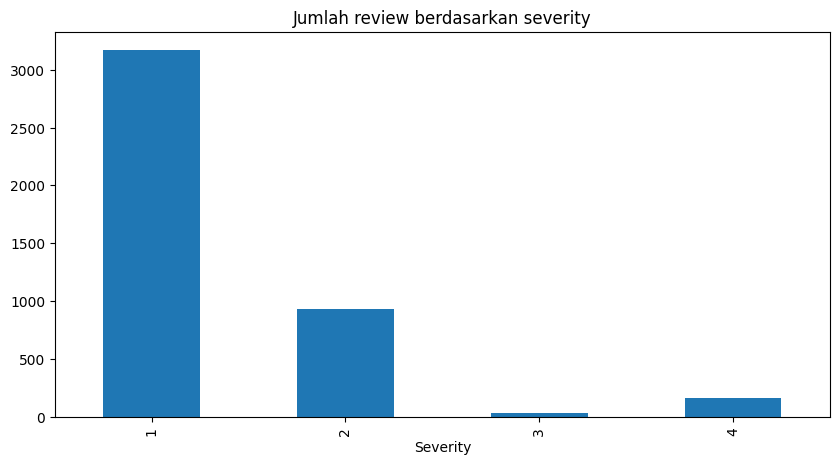

In [146]:
# Fungsi untuk menetapkan level kemarahan (severity) secara otomatis dengan kata kunci tertentu
def assign_severity_auto(text):
    # Mengubah semua huruf menjadi huruf kecil untuk memudahkan pencocokan teks
    text = str(text).lower()
    
    # Tingkat 4 (Blame): Pelanggan ingin berhenti atau menuntut tindakan drastis
    blame_phrases = ['cabut', 'berhenti langganan', 'pindah provider', 'putus langganan', 'tutup aja', 'kapok', 'pengen ganti', 'gak usah langganan', 'minta refund', 'berhenti']
    if any(phrase in text for phrase in blame_phrases):
        return 4
        
    # Tingkat 3 (Accusation): Pelanggan merasa kecewa atau marah terhadap kualitas layanan
    acc_phrases = ['kecewa', 'rugi', 'parah', 'payah', 'buruk', 'penipu', 'bohong', 'gak profesional', 'percuma bayar', 'gak niat', 'gimana sih', 'telat terus']
    if any(phrase in text for phrase in acc_phrases):
        return 3
        
    # Tingkat 2 (Disapproval): Pelanggan menyampaikan komplain teknis atas gangguan
    dis_phrases = ['lambat', 'lemot', 'los merah', 'gangguan', 'lelet', 'ngeleg', 'rto', 'bapuk', 'mati total', 'sering putus', 'gak ada sinyal', 'trouble', 'buffering', 'ping tinggi']
    if any(phrase in text for phrase in dis_phrases):
        return 2
        
    # Tingkat 1 (No Explicit Reproach): Hanya pertanyaan rutin soal tagihan/pembayaran tanpa konotasi marah kuat
    if re.search(r'\b(bayar|tf|transfer|tagihan|paket|promo|harga|pasang|konfirmasi|nyala|cek|bukti|ganti password|admin|masuk|berapa|wfh)\b', text):
        return 1
        
    # Jika sekadar laporan teknis biasa tanpa nada keras, masuk ke level 2
    if re.search(r'\b(mati|putus|los|ngelag|lag)\b', text):
        return 2

    # Jika tidak masuk kategori mana pun, beri nilai 0 (nanti akan difilter/dibuang)
    return 0

# PERBAIKAN: Gunakan 'case_folding' atau 'cleaning_text' alih-alih 'clean_text'
# Karena logikanya mencari kata/frasa asli ("berhenti langganan", "gimana sih"), 
# sedangkan 'clean_text' sudah melalui proses stemming ("henti langgan") dan stopword (banyak kata hilang).
data['severity'] = data['case_folding'].apply(assign_severity_auto)

# Mempertahankan original message di memori (membuang label 0)
data = data[data['severity'].isin([1, 2, 3, 4])].copy()

print("Distribusi Klasifikasi Severity:")
print(data['severity'].value_counts())

# Membuat folder output (jika belum ada) dan mengekspor hasil ke format CSV
os.makedirs('../output', exist_ok=True)
data.to_csv('../output/data_labeled_auto.csv', index=False)
data.reset_index(drop=True, inplace=True)

# Di sini bar chart ditempatkan karena 'severity' baru selesai dibuat 
ax = data['severity'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Jumlah review berdasarkan severity',
          figsize=(10, 5))
ax.set_xlabel('Severity')
plt.show()

# **EKSPLORASI DATA & WORDCLOUD**

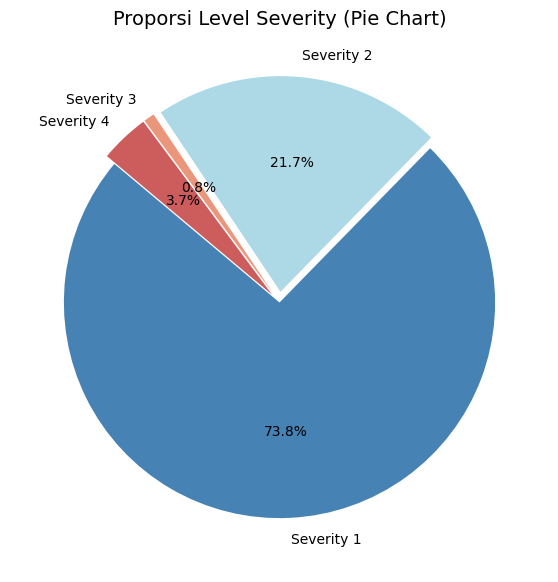

In [147]:
import matplotlib.pyplot as plt

# Menyiapkan data hitungan untuk tiap level severity
severity_counts = data['severity'].value_counts().sort_index()
labels = severity_counts.index
sizes = severity_counts.values

# 2. Visualisasi Pie Chart
fig, ax = plt.subplots(figsize=(7, 7))
explode = [0.05 if x != 1 else 0 for x in labels] # Memberikan efek pecahan kecil selain kelas mayoritas
ax.pie(sizes, labels=[f"Severity {l}" for l in labels], autopct='%1.1f%%', 
       colors=['steelblue', 'lightblue', 'darksalmon', 'indianred'], startangle=140, explode=explode, shadow=False)
ax.set_title('Proporsi Level Severity (Pie Chart)', fontsize=14)

plt.show()

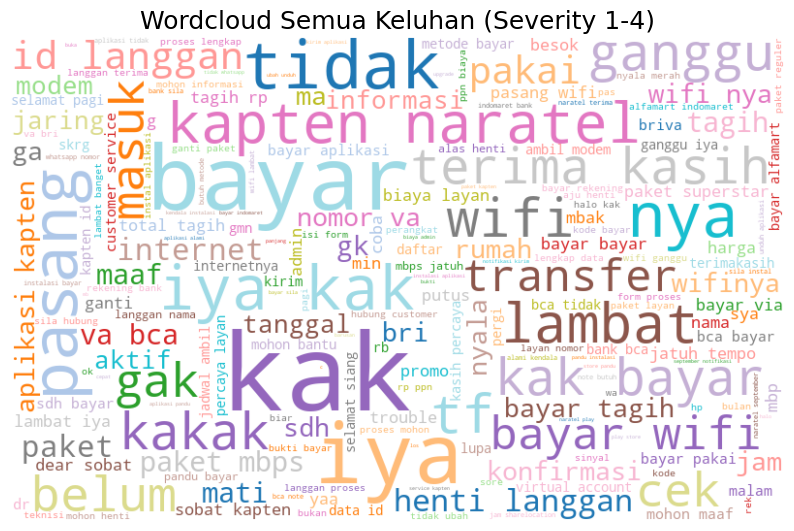

In [148]:
# Wordcloud untuk keseluruhan data yang telah diproses dan diberi label 1-4
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Menggabungkan semua teks yang telah bersih ke dalam satu string panjang
all_words = ' '.join([text for text in data['clean_text']])

# Menggunakan colormap='tab20' agar mirip dengan style shopee
word_cloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110, background_color='white', colormap='tab20').generate(all_words)

# Menampilkan visualisasi gambar WordCloud
plt.figure(figsize=(10, 7))
plt.imshow(word_cloud, interpolation="bilinear")
plt.axis('off')
plt.title('Wordcloud Semua Keluhan (Severity 1-4)', fontsize=18)
plt.show()

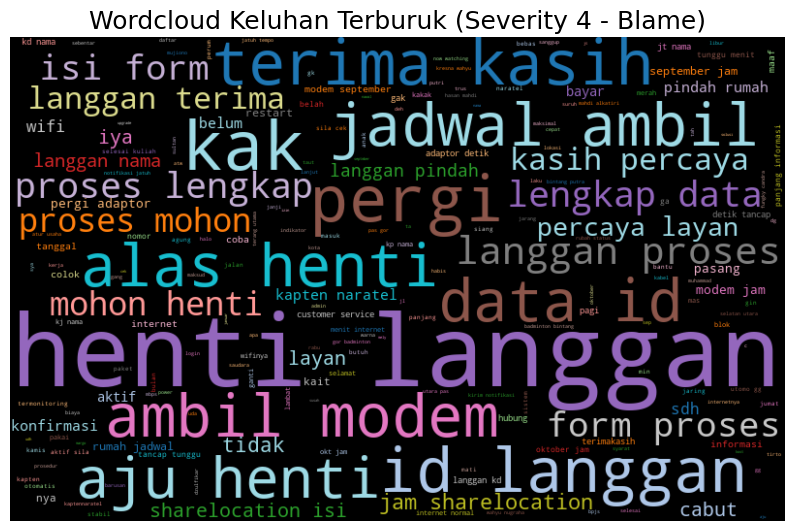

In [149]:
# Wordcloud khusus pelanggan yang berniat pergi / marah besar (Severity = 4, Blame)
severity_4_words = ' '.join([text for text in data['clean_text'][data['severity'] == 4]])

if len(severity_4_words.strip()) > 0:
    # Menggunakan colormap='tab20' agar mirip dengan style shopee
    word_cloud_4 = WordCloud(width=800, height=500, random_state=21, max_font_size=110, colormap='tab20').generate(severity_4_words)

    plt.figure(figsize=(10, 7))
    plt.imshow(word_cloud_4, interpolation="bilinear")
    plt.axis('off')
    plt.title('Wordcloud Keluhan Terburuk (Severity 4 - Blame)', fontsize=18)
    plt.show()
else:
    print("Tidak cukup data untuk membentuk visualisasi Wordcloud Severity 4.")

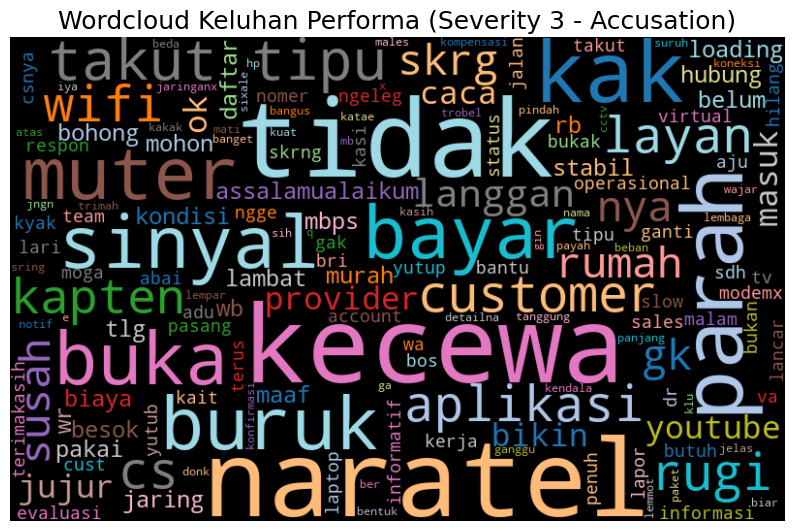

In [150]:
# Wordcloud khusus keluhan kualitas/teknis yang membuat frustrasi (Severity = 3, Accusation)
severity_3_words = ' '.join([text for text in data['clean_text'][data['severity'] == 3]])

if len(severity_3_words.strip()) > 0:
    # Menggunakan colormap='tab20' agar mirip dengan style shopee
    word_cloud_3 = WordCloud(width=800, height=500, random_state=21, max_font_size=110, colormap='tab20').generate(severity_3_words)

    plt.figure(figsize=(10, 7))
    plt.imshow(word_cloud_3, interpolation="bilinear")
    plt.axis('off')
    plt.title('Wordcloud Keluhan Performa (Severity 3 - Accusation)', fontsize=18)
    plt.show()
else:
    print("Tidak cukup data untuk membentuk visualisasi Wordcloud Severity 3.")

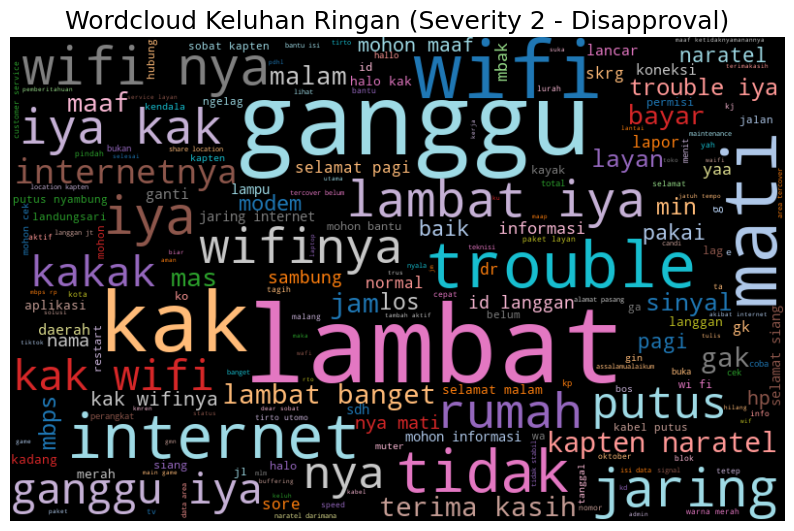

In [151]:
# Wordcloud khusus keluhan teknis ringan / ketidakpuasan awal (Severity = 2, Disapproval)
severity_2_words = ' '.join([text for text in data['clean_text'][data['severity'] == 2]])

if len(severity_2_words.strip()) > 0:
    # Menggunakan colormap='tab20' agar mirip dengan style shopee
    word_cloud_2 = WordCloud(width=800, height=500, random_state=21, max_font_size=110, colormap='tab20').generate(severity_2_words)

    plt.figure(figsize=(10, 7))
    plt.imshow(word_cloud_2, interpolation="bilinear")
    plt.axis('off')
    plt.title('Wordcloud Keluhan Ringan (Severity 2 - Disapproval)', fontsize=18)
    plt.show()
else:
    print("Tidak cukup data untuk membentuk visualisasi Wordcloud Severity 2.")

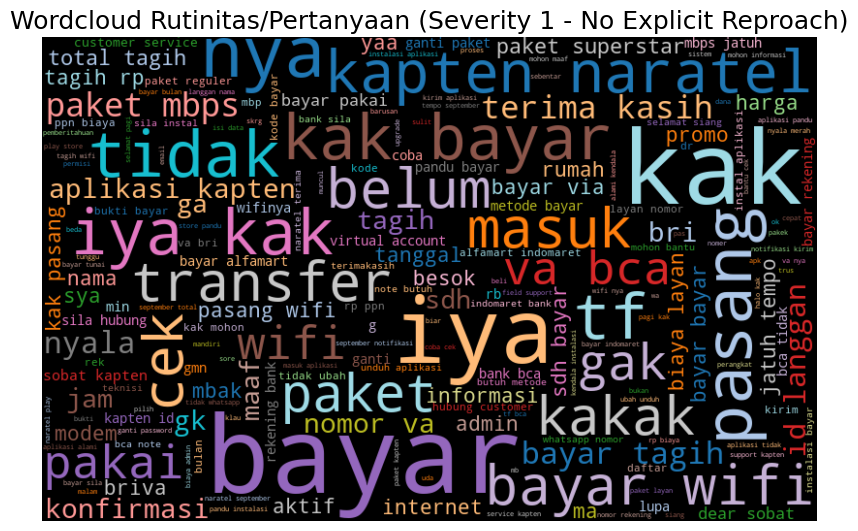

In [152]:
# Wordcloud khusus pertanyaan/rutinitas (Severity = 1, No Explicit Reproach)
severity_1_words = ' '.join([text for text in data['clean_text'][data['severity'] == 1]])

if len(severity_1_words.strip()) > 0:
    # Menggunakan colormap='tab20' agar mirip dengan style shopee
    word_cloud_1 = WordCloud(width=800, height=500, random_state=21, max_font_size=110, colormap='tab20').generate(severity_1_words)

    plt.figure(figsize=(10, 7))
    plt.imshow(word_cloud_1, interpolation="bilinear")
    plt.axis('off')
    plt.title('Wordcloud Rutinitas/Pertanyaan (Severity 1 - No Explicit Reproach)', fontsize=18)
    plt.show()
else:
    print("Tidak cukup data untuk membentuk visualisasi Wordcloud Severity 1.")

# **5. FEATURE SELECTION / EXTRACTION**

In [153]:
# 1. Feature Extraction (TF-IDF)
# Mengubah teks menjadi format angka (vektor bobot) berdasarkan frekuensi kemunculan (TF) 
# dan membaginya dengan frekuensi lintas dokumen (IDF).
tfidf = TfidfVectorizer(max_features=5000)

# fit_transform() mengonversi seluruh kalimat teks yang sudah ada pada Pandas Series menjadi array
X = tfidf.fit_transform(data['clean_text']).toarray()

# Mengambil parameter target (y) yaitu class Label sentimen severity yang sebelumnya kita mapping
y = data['severity'].values

print("Shape X (Feature):", X.shape)
print("Shape y (Target):", y.shape)

Shape X (Feature): (4294, 2616)
Shape y (Target): (4294,)


In [154]:
# 2. Train-Test Split 80:20
# Kita sisihkan 20% data secara acak untuk keperluan testing model.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training MultinomialNB
# Model yang dipilih karena sesuai blueprint (khusus perhitungan text-based bayesian)
clf_nb = MultinomialNB()
clf_nb.fit(X_train, y_train)

# 4. Predict
# Hasil prediksi model terhadap data Uji 
y_pred_nb = clf_nb.predict(X_test)

## **EVALUASI**
Akurasi, Precision, Recall, F1 Score & Confusion Matrix

===== Multinomial Naive Bayes =====
Accuracy   : 0.9126891734575088
Precision  : 0.7123924754539925
Recall     : 0.5484310055710528
F1-score   : 0.5947399920800633

Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.99      0.95       615
           2       0.95      0.81      0.88       198
           3       0.00      0.00      0.00        15
           4       1.00      0.39      0.56        31

    accuracy                           0.91       859
   macro avg       0.71      0.55      0.59       859
weighted avg       0.90      0.91      0.90       859



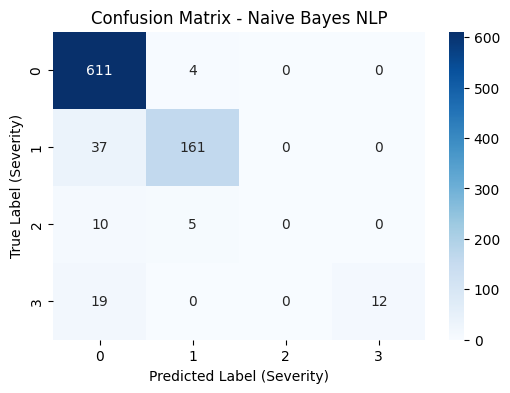

In [155]:
print("===== Multinomial Naive Bayes =====")
print("Accuracy   :", accuracy_score(y_test, y_pred_nb))
# Gunakan macro untuk melihat keseimbangan antar keempat kelas
print("Precision  :", precision_score(y_test, y_pred_nb, average='macro', zero_division=0))
print("Recall     :", recall_score(y_test, y_pred_nb, average='macro', zero_division=0))
print("F1-score   :", f1_score(y_test, y_pred_nb, average='macro', zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

# Confusion Matrix Visual
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes NLP")
plt.xlabel('Predicted Label (Severity)')
plt.ylabel('True Label (Severity)')
plt.show()

===== Complement Naive Bayes (Handling Imbalance) =====
Accuracy   : 0.9394644935972061
Precision  : 0.7714396818986939
Recall     : 0.8462530497738995

Classification Report CNB:
              precision    recall  f1-score   support

           1       0.98      0.95      0.97       615
           2       0.89      0.93      0.91       198
           3       0.42      0.53      0.47        15
           4       0.79      0.97      0.87        31

    accuracy                           0.94       859
   macro avg       0.77      0.85      0.80       859
weighted avg       0.94      0.94      0.94       859



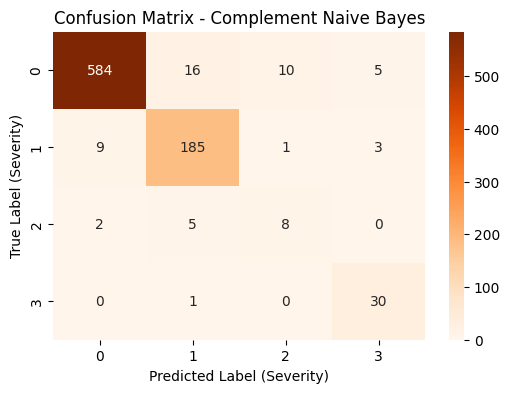

In [156]:
# SOLUSI 1: MENGGUNAKAN COMPLEMENT NAIVE BAYES (CNB)
from sklearn.naive_bayes import ComplementNB

# 1. Train-Test Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Model Training dengan ComplementNB
clf_cnb = ComplementNB()
clf_cnb.fit(X_train, y_train)

# 3. Predict
y_pred_cnb = clf_cnb.predict(X_test)

print("===== Complement Naive Bayes (Handling Imbalance) =====")
print("Accuracy   :", accuracy_score(y_test, y_pred_cnb))
print("Precision  :", precision_score(y_test, y_pred_cnb, average='macro', zero_division=0))
print("Recall     :", recall_score(y_test, y_pred_cnb, average='macro', zero_division=0))

print("\nClassification Report CNB:")
print(classification_report(y_test, y_pred_cnb, zero_division=0))

# Confusion Matrix Visual CNB
cm_cnb = confusion_matrix(y_test, y_pred_cnb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Complement Naive Bayes")
plt.xlabel('Predicted Label (Severity)')
plt.ylabel('True Label (Severity)')
plt.show()

===== SMOTE + Multinomial Naive Bayes =====
Accuracy   : 0.9243306169965075
Precision  : 0.7723268294245803
Recall     : 0.8658308100676315

Classification Report SMOTE:
              precision    recall  f1-score   support

           1       0.99      0.93      0.96       615
           2       0.86      0.93      0.89       198
           3       0.67      0.67      0.67        15
           4       0.58      0.94      0.72        31

    accuracy                           0.92       859
   macro avg       0.77      0.87      0.81       859
weighted avg       0.94      0.92      0.93       859



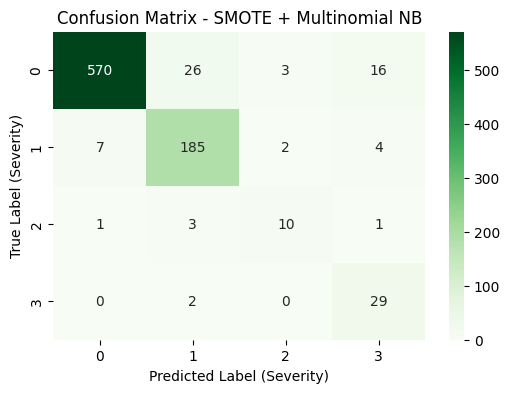

In [157]:
# SOLUSI 2: MENGGUNAKAN OVERSAMPLING (SMOTE) + MULTINOMIAL NAIVE BAYES
from imblearn.over_sampling import SMOTE

# Aplikasikan SMOTE hanya pada data latih (Train)
smote = SMOTE(random_state=42, k_neighbors=1) 
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Model Training
clf_smote = MultinomialNB()
clf_smote.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred_smote = clf_smote.predict(X_test)

print("===== SMOTE + Multinomial Naive Bayes =====")
print("Accuracy   :", accuracy_score(y_test, y_pred_smote))
print("Precision  :", precision_score(y_test, y_pred_smote, average='macro', zero_division=0))
print("Recall     :", recall_score(y_test, y_pred_smote, average='macro', zero_division=0))

print("\nClassification Report SMOTE:")
print(classification_report(y_test, y_pred_smote, zero_division=0))

# Confusion Matrix Visual SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - SMOTE + Multinomial NB")
plt.xlabel('Predicted Label (Severity)')
plt.ylabel('True Label (Severity)')
plt.show()

# **OUTPUT NLP**

In [158]:
# Terapkan prediksi ke seluruh dataset 'data' untuk dibawa ke model Decision Tree
y_pred_all = clf_nb.predict(X)

data['predicted_severity'] = y_pred_all

# Hanya ambil kolom penting 
final_nlp_output = data[['kode_user', 'message', 'clean_text', 'severity', 'predicted_severity']]

# Export ke output
final_nlp_output.to_csv('../output/data_with_severity.csv', index=False)

print("Distribusi Predicted Severity:\n", final_nlp_output['predicted_severity'].value_counts())
print("\nHasil disimpan ke output/data_with_severity.csv")
final_nlp_output.head()

Distribusi Predicted Severity:
 predicted_severity
1    3426
2     816
4      52
Name: count, dtype: int64

Hasil disimpan ke output/data_with_severity.csv


,kode_user,message,clean_text,severity,predicted_severity
0,KN0627,Brarti 450k 100mbps utk 3bulan tanpa bayar mod...,brarti mbps bayar modem iya kak,1,1
1,KP2257,Ini bukti tf.nya kak,bukti tf nya kak,1,1
2,"KM0752, KM1492",Bentar mb tunggu info yg di rumah sdh nyala be...,sebentar mb tunggu informasi rumah sdh nyala b...,1,1
3,JT0290,Kapten naratel gangguan ya,kapten naratel ganggu iya,2,2
4,"KJ2224, KI1388",Kak nomor wa untuk lapor gangguan nya ganti kah?,kak nomor wa lapor ganggu nya ganti,2,1
